In [75]:
import pandas as pd

from rdkit.Chem import CanonSmiles, RemoveStereochemistry, MolFromSmiles, MolToInchi
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit import RDLogger

from pathlib import Path

RDLogger.DisableLog('rdApp.*')

### Download data, construct DFs

In [76]:
df = pd.read_csv(r"https://raw.githubusercontent.com/fart-lab/fart/refs/heads/main/dataset/fart_curated.csv", index_col=0)
df_train = pd.read_csv(r"https://raw.githubusercontent.com/fart-lab/fart/refs/heads/main/dataset/splits/fart_train.csv", index_col=0)
df_val = pd.read_csv(r"https://raw.githubusercontent.com/fart-lab/fart/refs/heads/main/dataset/splits/fart_val.csv", index_col=0)
df_test = pd.read_csv(r"https://raw.githubusercontent.com/fart-lab/fart/refs/heads/main/dataset/splits/fart_test.csv", index_col=0)

### Workup the data

In [77]:
df["smiles"] = list(map(CanonSmiles, df["Canonicalized SMILES"]))

In [78]:
label_ids = {label: i for i, label in enumerate(df['Canonicalized Taste'].unique())}
num_classes = max(label_ids.values()) + 1

In [79]:
df["target"] = df['Canonicalized Taste'].map(label_ids)
df.head(4)

,Canonicalized SMILES,Standardized SMILES,Canonicalized Taste,Original Labels,Source,is_multiclass,smiles,target
0,Oc1cc2c(cc1O)C1c3ccc(O)c(O)c3OCC1(O)C2,Oc1cc2c(cc1O)C1c3ccc(O)c(O)c3OCC1(O)C2,sweet,"Sweet, Sweetness",chemtastes_db,0,Oc1cc2c(cc1O)C1c3ccc(O)c(O)c3OCC1(O)C2,0
1,CC(C)=CCCC(C)(O)C1CC(O)C(C)=CC1=O,CC(C)=CCCC(C)(O)C1CC(O)C(C)=CC1=O,sweet,"Sweet, Sweetness",chemtastes_db,0,CC(C)=CCCC(C)(O)C1CC(O)C(C)=CC1=O,0
2,CC(=O)OC1C(=O)c2c(O)cc(O)cc2OC1c1ccc(O)c(O)c1,CC(=O)OC1C(=O)c2c(O)cc(O)cc2OC1c1ccc(O)c(O)c1,sweet,"Sweet, Sweetness",chemtastes_db,0,CC(=O)OC1C(=O)c2c(O)cc(O)cc2OC1c1ccc(O)c(O)c1,0
3,OC1C(O)C(O)C(O)C(O)C1O,OC1C(O)C(O)C(O)C(O)C1O,sweet,"Sweet, Sweetness",chemtastes_db,0,OC1C(O)C(O)C(O)C(O)C1O,0


In [6]:
df.to_csv("data/zimmermann_et_al_flavors_original.csv", index=False)

### Analyze the dataset(s)

In [80]:
# Get stereoisomer and tautomer duplicates.
mol_list = df['Canonicalized SMILES'].apply(lambda x: MolFromSmiles(x))

In [81]:
import copy
remover = SaltRemover()

def get_sanitized_inchi(original_mol) -> str:
    '''
    Given a mol object, return an InChI string sanitized of stereochemistry, tautomerization, salt status.
    '''
    def check_mol(old_mol, new_mol):
        if not new_mol:
            outstr = MolToInchi(old_mol)
            print(f"No mol detected for: {outstr}")
            return outstr
    
        if new_mol.GetNumAtoms() == 0:
            outstr = MolToInchi(old_mol)
            print(f"Number of atoms 0 for: {outstr}")
            return outstr

    # stereochem
    mol = copy.deepcopy(original_mol)
    RemoveStereochemistry(mol)
    outstr = check_mol(original_mol, mol)
    if outstr: return outstr

    # enumerate tautoemrs
    enumerator = rdMolStandardize.TautomerEnumerator()
    enum_mol = enumerator.Canonicalize(mol)
    outstr = check_mol(mol, enum_mol)
    if outstr: return outstr

    # strip salt/ions
    strip_mol = remover.StripMol(enum_mol)
    outstr = check_mol(enum_mol, strip_mol)
    if outstr: return outstr

    return MolToInchi(strip_mol)


In [82]:
loading = True
file_path = Path("zimmermann_et_al_flavors_extra_labels.csv")

# Timely calculation!
if file_path.exists() and loading:
   df = pd.read_csv(file_path)
else:
    print("Sanitizing InChI (warning: costly operation, may take between 15-60 minutes)")
    df['sanitized_inchi'] = mol_list.apply(lambda x: get_sanitized_inchi(x))

Sanitizing InChI (warning: costly operation, may take between 15-60 minutes)
Number of atoms 0 for: InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)
Number of atoms 0 for: InChI=1S/C2H2O4/c3-1(4)2(5)6/h(H,3,4)(H,5,6)
Number of atoms 0 for: InChI=1S/H3N/h1H3
Number of atoms 0 for: InChI=1S/H2O/h1H2
Number of atoms 0 for: InChI=1S/2C2H4O2.Na/c2*1-2(3)4;/h2*1H3,(H,3,4);/q;;+1/p-1
Number of atoms 0 for: InChI=1S/C4H4O4/c5-3(6)1-2-4(7)8/h1-2H,(H,5,6)(H,7,8)
Number of atoms 0 for: InChI=1S/C4H6O6/c5-1(3(7)8)2(6)4(9)10/h1-2,5-6H,(H,7,8)(H,9,10)
Number of atoms 0 for: InChI=1S/C4H6O6/c5-1(3(7)8)2(6)4(9)10/h1-2,5-6H,(H,7,8)(H,9,10)
Number of atoms 0 for: InChI=1S/C4H6O6/c5-1(3(7)8)2(6)4(9)10/h1-2,5-6H,(H,7,8)(H,9,10)
Number of atoms 0 for: InChI=1S/C4H4O4/c5-3(6)1-2-4(7)8/h1-2H,(H,5,6)(H,7,8)
Number of atoms 0 for: InChI=1S/C4H4O4/c5-3(6)1-2-4(7)8/h1-2H,(H,5,6)(H,7,8)
Number of atoms 0 for: InChI=1S/H3O4P/c1-5(2,3)4/h(H3,1,2,3,4)
Number of atoms 0 for: InChI=1S/H3O4P/c1-5(2,3)4/h(H3,1,2,3,4)


In [123]:
# Get points with poor evidence.
BAD_LABELS = ["insufficient evidence", "contradictory evidence", "low evidence", "negative evidence"]
NON_BITTER_LABELS = ["not bitter", "non bitter", "non-bitter",]

def check_for_bad_evidence(label : str, taste : str) -> int:
    for bad_label in BAD_LABELS:
        if bad_label in label.lower():
            return 1

    for nonbitter_label in NON_BITTER_LABELS:
        if nonbitter_label in label.lower() and taste == "bitter":
            return 1

    return 0

df['bad_evidence'] = df.apply(lambda x: check_for_bad_evidence(x['Original Labels'], x['Canonicalized Taste']), axis=1)
df[df['bad_evidence'] == 1].shape

(117, 10)

In [124]:
df.to_csv("data/zimmermann_et_al_flavors_extra_labels.csv", index=False)

### Check the train+val / test splits for data leakage.

In [125]:
# get canonicalized strings
smiles_to_inchi_map = dict(zip(df['Canonicalized SMILES'], df['sanitized_inchi']))

df_trainval = pd.concat([df_train, df_val])
df_trainval['sanitized_inchi'] = df_trainval['Canonicalized SMILES'].apply(lambda x: smiles_to_inchi_map[x])
df_test['sanitized_inchi'] = df_test['Canonicalized SMILES'].apply(lambda x: smiles_to_inchi_map[x])

In [126]:
### get overlaps
overlaps = pd.merge(df_trainval, df_test, on='sanitized_inchi', how='inner')
overlaps[(overlaps['is_multiclass_x'] == 0) ]

,Canonicalized SMILES_x,Standardized SMILES_x,Canonicalized Taste_x,Original Labels_x,Source_x,is_multiclass_x,sanitized_inchi,Canonicalized SMILES_y,Standardized SMILES_y,Canonicalized Taste_y,Original Labels_y,Source_y,is_multiclass_y
0,COc1cc(C(=O)OCC(C#N)=CCOC2OC(CO)C(O)C(O)C2O)ccc1O,COc1cc(C(=O)OCC(C#N)=CCOC2OC(CO)C(O)C(O)C2O)ccc1O,undefined,"Astringent, Miscellaneous",chemtastes_db,0,InChI=1S/C19H23NO10/c1-27-13-6-11(2-3-12(13)22...,COc1cc(C(=O)OC/C(C#N)=C/COC2OC(CO)C(O)C(O)C2O)...,COc1cc(C(=O)OC/C(C#N)=C/COC2OC(CO)C(O)C(O)C2O)...,undefined,astringent;,phytocompounds_db,0
1,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,sweet,sweet-like,flavor_db,0,InChI=1S/C12H22O11/c13-1-3-5(15)6(16)9(19)12(2...,O=S(=O)([O-])[O-].OCC1OC(OC2C(CO)OC(O)C(O)C2O)...,O=S(=O)([O-])[O-].OCC1OC(OC2C(CO)OC(O)C(O)C2O)...,sweet,sweet,flavor_db,0
2,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,sweet,sweet-like,flavor_db,0,InChI=1S/C12H22O11/c13-1-3-5(15)6(16)9(19)12(2...,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,sweet,sweet,flavor_db,0
3,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,sweet,"Sweet, Sweetness",chemtastes_db,0,InChI=1S/C12H22O11/c13-1-3-5(15)6(16)9(19)12(2...,O=S(=O)([O-])[O-].OCC1OC(OC2C(CO)OC(O)C(O)C2O)...,O=S(=O)([O-])[O-].OCC1OC(OC2C(CO)OC(O)C(O)C2O)...,sweet,sweet,flavor_db,0
4,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,sweet,"Sweet, Sweetness",chemtastes_db,0,InChI=1S/C12H22O11/c13-1-3-5(15)6(16)9(19)12(2...,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O.[Cl-]....,sweet,sweet,flavor_db,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,NCC(=O)NCC(=O)NC(Cc1ccccc1)C(=O)O,NCC(=O)NCC(=O)NC(Cc1ccccc1)C(=O)O,sweet,sweet,flavor_db,0,InChI=1S/C13H17N3O4/c14-7-11(17)15-8-12(18)16-...,[NH3+]CC(=O)NCC(=O)NC(Cc1ccccc1)C(=O)[O-],[NH3+]CC(=O)NCC(=O)NC(Cc1ccccc1)C(=O)[O-],sweet,sweet,flavor_db,0
83,O=S(=O)([O-])[O-].OCC1OC(OC2(CO)OC(CO)C(O)C2O)...,O=S(=O)([O-])[O-].OCC1OC(OC2(CO)OC(CO)C(O)C2O)...,sweet,sweet,flavor_db,0,InChI=1S/C12H22O11.Al/c13-1-4-6(16)8(18)9(19)1...,OCC1OC(OC2(CO)OC(CO)C(O)C2O)C(O)C(O)C1O.[Al+3]...,OCC1OC(OC2(CO)OC(CO)C(O)C2O)C(O)C(O)C1O.[Al+3]...,sweet,sweet,flavor_db,0
84,CC(C)c1cccc(O)c(=O)c1,CC(C)c1cccc(O)c(=O)c1,undefined,"woody, phenolic",flavor_db,0,InChI=1S/C10H12O2/c1-7(2)8-4-3-5-9(11)10(12)6-...,CC(C)c1cccc(=O)c(O)c1,CC(C)c1cccc(=O)c(O)c1,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0
85,O=C(C(=O)C(O)C(O)CO)C(O)CO,O=C(C(=O)C(O)C(O)CO)C(O)CO,sweet,sweet-like,flavor_db,0,InChI=1S/C7H12O7/c8-1-3(10)5(12)7(14)6(13)4(11...,O=CC(=O)C(O)C(O)C(O)C(O)CO,O=CC(=O)C(O)C(O)C(O)C(O)CO,sweet,sweet,flavor_db,0


In [127]:
# number of overlaps with identical labels
overlaps[(overlaps['is_multiclass_x'] == 0) & (overlaps['Canonicalized Taste_x'] == overlaps['Canonicalized Taste_y'])].shape

(72, 13)

In [128]:
# overlaps with different labels
overlaps[(overlaps['is_multiclass_x'] == 0) & (overlaps['Canonicalized Taste_x'] != overlaps['Canonicalized Taste_y'])]

,Canonicalized SMILES_x,Standardized SMILES_x,Canonicalized Taste_x,Original Labels_x,Source_x,is_multiclass_x,sanitized_inchi,Canonicalized SMILES_y,Standardized SMILES_y,Canonicalized Taste_y,Original Labels_y,Source_y,is_multiclass_y
44,CC(=O)C=CC1C(C)=CCCC1(C)C,CC(=O)C=CC1C(C)=CCCC1(C)C,sweet,"floral, sweet, woody, tropical, fruity, wood, ...",flavor_db,0,"InChI=1S/C13H20O/c1-10-6-5-9-13(3,4)12(10)8-7-...",C=C1CCCC(C)(C)C1C=CC(C)=O,C=C1CCCC(C)(C)C1C=CC(C)=O,undefined,"floral, woody",flavor_db,0
61,Nc1nc(=O)c2nc(CNc3ccc(C(=O)NC(CCC(=O)O)C(=O)O)...,Nc1nc(=O)c2nc(CNc3ccc(C(=O)NC(CCC(=O)O)C(=O)O)...,undefined,odorless,flavor_db,0,InChI=1S/C19H19N7O6/c20-19-25-15-14(17(30)26-1...,Nc1nc2ncc(CNc3ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc3)...,Nc1nc2ncc(CNc3ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc3)...,sweet,sweet (insufficient evidence),phytocompounds_db,0
84,CC(C)c1cccc(O)c(=O)c1,CC(C)c1cccc(O)c(=O)c1,undefined,"woody, phenolic",flavor_db,0,InChI=1S/C10H12O2/c1-7(2)8-4-3-5-9(11)10(12)6-...,CC(C)c1cccc(=O)c(O)c1,CC(C)c1cccc(=O)c(O)c1,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0
86,CC(=O)C=C(C)C,CC(=O)C=C(C)C,sweet,"acrylic, vegetable, chemical, earthy, sweet, p...",flavor_db,0,"InChI=1S/C6H10O/c1-5(2)4-6(3)7/h4H,1-3H3",C=C(C)CC(C)=O,C=C(C)CC(C)=O,undefined,"acrylic, vegetable, pungent",flavor_db,0


In [287]:
overlaps.to_csv("data/original_trainval_test_data_leakage.csv", index=False)

# Apply improvements

In [277]:
# We want to keep the columns we drop. 
dropped = []

Get rid of anything from the IUPAC database

In [278]:
print(f"{df.shape[0]} original molecules")
df_sanitized = df.copy()
mask = df_sanitized['Source'] == "IUPAC Dissocation Constants"
dropped.append(df_sanitized[mask].assign(drop_reason="pKa Data"))
df_sanitized = df_sanitized[~mask]

print(f"{df_sanitized.shape[0]} molecules after pruning")

15025 original molecules
13512 molecules after pruning


Remove points with "insufficient evidence", "contradictory evidence", "low evidence", "negative evidence", "not bitter", "non bitter"

In [279]:
mask = df_sanitized['bad_evidence'] == 1
dropped.append(df_sanitized[mask].assign(drop_reason="Bad label"))
df_sanitized = df_sanitized[~mask]
print(f"{df_sanitized.shape[0]} molecules after pruning")

13395 molecules after pruning


Get rid of entries with multiple labels.,

In [280]:
duplicated_smiles = df_sanitized[df_sanitized.duplicated("smiles", keep=False)]
dropped.append(duplicated_smiles.assign(drop_reason="Non-unique SMILES"))
df_sanitized = df_sanitized.drop_duplicates("smiles", keep=False)
print(f"{df_sanitized.shape[0]} molecules after pruning SMILES (multi-label)")

12634 molecules after pruning SMILES (multi-label)


A POSSIBLE IMPROVEMENT WE COULD MAKE: convert "fruity", "apple" etc to "sweet"; but out-of-scope.

Get rid of duplicates based on stereoisomers and salt forms.


In [281]:
grouped = df_sanitized.groupby("sanitized_inchi")
inconsistent_inchis = grouped.filter(
    lambda g: g["Canonicalized Taste"].nunique() != 1
)
dropped.append(inconsistent_inchis.assign(drop_reason="InChI-duplicate with conflicting taste"))

# keep groups with consistent taste only
consistent_inchis = grouped.filter(
    lambda g: g["Canonicalized Taste"].nunique() == 1
)
#
keep_mask = consistent_inchis.duplicated("sanitized_inchi", keep="first")
dupe_inchis_dropped = consistent_inchis[keep_mask]
dropped.append(dupe_inchis_dropped.assign(drop_reason="InChI-duplicate with same taste"))

df_sanitized = consistent_inchis.drop_duplicates("sanitized_inchi", keep="first").reset_index(drop=True)

# To drop everything, can just do this:
#df_sanitized = df_sanitized.drop_duplicates("sanitized_inchi", keep=False)

print(f"{df_sanitized.shape[0]} molecules after pruning stereochemistry/InChI")

12486 molecules after pruning stereochemistry/InChI


Finally, plot and combine the dropped data

<AxesSubplot: >

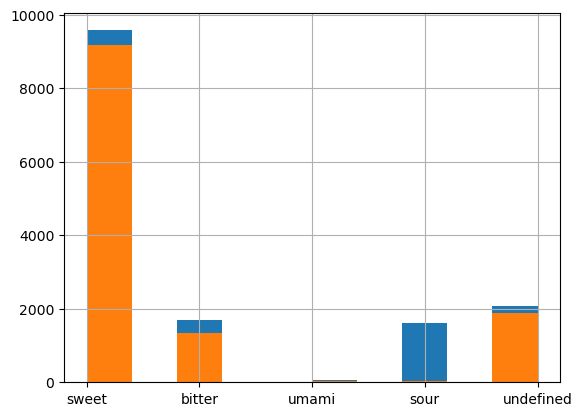

In [282]:
df['Canonicalized Taste'].hist()
df_sanitized['Canonicalized Taste'].hist()

In [283]:
df_dropped = pd.concat(dropped, ignore_index=True)
df_dropped

,Canonicalized SMILES,Standardized SMILES,Canonicalized Taste,Original Labels,Source,is_multiclass,smiles,target,sanitized_inchi,bad_evidence,drop_reason
0,NCCOP(=O)(O)O,NCCOP(=O)(O)O,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0,NCCOP(=O)(O)O,3,"InChI=1S/C2H8NO4P/c3-1-2-7-8(4,5)6/h1-3H2,(H2,...",0,pKa Data
1,Nc1ccccc1S,Nc1ccccc1S,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0,Nc1ccccc1S,3,"InChI=1S/C6H7NS/c7-5-3-1-2-4-6(5)8/h1-4,8H,7H2",0,pKa Data
2,O=C(O)c1ccccn1,O=C(O)c1ccccn1,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0,O=C(O)c1ccccn1,3,"InChI=1S/C6H5NO2/c8-6(9)5-3-1-2-4-7-5/h1-4H,(H...",0,pKa Data
3,O=C(O)c1ccncc1,O=C(O)c1ccncc1,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0,O=C(O)c1ccncc1,3,"InChI=1S/C6H5NO2/c8-6(9)5-1-3-7-4-2-5/h1-4H,(H...",0,pKa Data
4,Cn1cc(C(=O)O)ccc1=O,Cn1cc(C(=O)O)ccc1=O,sour,pKa between 2 and 7,IUPAC Dissocation Constants,0,Cn1cc(C(=O)O)ccc1=O,3,InChI=1S/C7H7NO3/c1-8-4-5(7(10)11)2-3-6(8)9/h2...,0,pKa Data
...,...,...,...,...,...,...,...,...,...,...,...
2534,CC(C)=CCC1=C(O)C(C(=O)CC(C)C)=C(O)C1O,CC(C)=CCC1=C(O)C(C(=O)CC(C)C)=C(O)C1O,bitter,bitter,phytocompounds_db,0,CC(C)=CCC1=C(O)C(C(=O)CC(C)C)=C(O)C1O,1,InChI=1S/C15H22O4/c1-8(2)5-6-10-13(17)12(15(19...,0,InChI-duplicate with same taste
2535,COc1cc(C(=O)OC/C(C#N)=C/COC2OC(CO)C(O)C(O)C2O)...,COc1cc(C(=O)OC/C(C#N)=C/COC2OC(CO)C(O)C(O)C2O)...,undefined,astringent;,phytocompounds_db,0,COc1cc(C(=O)OC/C(C#N)=C/COC2OC(CO)C(O)C(O)C2O)...,4,InChI=1S/C19H23NO10/c1-27-13-6-11(2-3-12(13)22...,0,InChI-duplicate with same taste
2536,N#C/C(=C\COC1OC(CO)C(O)C(O)C1O)COC(=O)c1ccc(O)cc1,N#C/C(=C\COC1OC(CO)C(O)C(O)C1O)COC(=O)c1ccc(O)cc1,undefined,astringent;,phytocompounds_db,0,N#C/C(=C\COC1OC(CO)C(O)C(O)C1O)COC(=O)c1ccc(O)cc1,4,InChI=1S/C18H21NO9/c19-7-10(9-27-17(25)11-1-3-...,0,InChI-duplicate with same taste
2537,CC1CC(OC2OC(CO)C(O)C(O)C2O)CC(=O)O1,CC1CC(OC2OC(CO)C(O)C(O)C2O)CC(=O)O1,bitter,bitter,phytocompounds_db,0,CC1CC(OC2OC(CO)C(O)C(O)C2O)CC(=O)O1,1,InChI=1S/C12H20O8/c1-5-2-6(3-8(14)18-5)19-12-1...,0,InChI-duplicate with same taste


### save out

In [285]:
df_dropped = pd.concat(dropped, ignore_index=True)

# Check that we did it all correctly
parity = df.shape[0] - df_sanitized.shape[0] - df_dropped.shape[0]
if parity != 0:
    print(f"WARNING: df_dropped does not match df_sanitized. {parity} entries mismatch.")

### Save out

In [286]:
df_sanitized.to_csv("data/zimmermann_et_al_flavors_sanitized.csv", index=False)
df_dropped.to_csv("data/zimmermann_et_al_flavors_dropped_during_sanitization.csv", index=False)